In [9]:
import joblib
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [10]:
# Laden des Baseline-Modells
baselin_t1 = joblib.load("baseline_model_gcs_t+1.pkl")
baselin_t2 = joblib.load("baseline_model_gcs_t+2.pkl")
baselin_t3 = joblib.load("baseline_model_gcs_t+3.pkl")

# Laden des Keras-Modells
model_t1 = load_model("dl_model_gcs_t+1.h5", compile=False)
model_t2 = load_model("dl_model_gcs_t+2.h5", compile=False)
model_t3 = load_model("dl_model_gcs_t+3.h5", compile=False)

In [11]:
# Daten laden
df = pd.read_csv("gcs_features.csv")
df = df.sort_values(by=["subject_id", "window_start"])
df["gcs_t+1"] = df.groupby("subject_id")["gcs_total"].shift(-1)
df["gcs_t+2"] = df.groupby("subject_id")["gcs_total"].shift(-2)
df["gcs_t+3"] = df.groupby("subject_id")["gcs_total"].shift(-3)
df = df.dropna(subset=["gcs_t+1", "gcs_t+2", "gcs_t+3"])

features = ['heart_rate', 'systolic_bp', 'diastolic_bp', 'temperature', 'creatinine', 'hemoglobin']
df[features] = df[features].fillna(df[features].median())

# Skalierung
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
def evaluate_and_plot(model, baseline, X_scaled, y, label):
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

    # Vorhersagen
    y_pred = model.predict(X_scaled).flatten()
    y_base = baseline.predict(X_scaled)
    residuals = y_pred - y

    # === Metriken ===
    def metrics(y_true, y_pred, name):
        print(f"\n{name} Metriken:")
        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true, y_pred)
        mape = mean_absolute_percentage_error(y_true, y_pred)

        print(f"MAE:  {mae:.2f}")
        print(f"MSE:  {mse:.2f}")
        print(f"RMSE: {rmse:.2f}")
        print(f"R²:   {r2:.2f}")
        print(f"MAPE: {mape*100:.2f}%")

    metrics(y, y_base, f"Baseline ({label})")
    metrics(y, y_pred, f"DL Modell ({label})")

    fig, axs = plt.subplots(2, 1, figsize=(12, 10))

    # Streudiagramm
    axs[0].scatter(y, y_pred, alpha=0.4, label='DL')
    axs[0].scatter(y, y_base, alpha=0.4, label='Baseline', marker='x')
    axs[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Ideal')
    axs[0].set_title('Vorhergesagt vs. Tatsächlich')
    axs[0].set_xlabel('Tatsächlich')
    axs[0].set_ylabel('Vorhergesagt')
    axs[0].legend()

    # Histogramm der Fehler
    axs[1].hist(residuals, bins=30, color='gray', edgecolor='black')
    axs[1].set_title('Fehlerverteilung')
    axs[1].set_xlabel('Fehler')
    axs[1].set_ylabel('Häufigkeit')

    plt.suptitle(f"Evaluation für {label}")
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 685us/step

Baseline (gcs_t+1) Metriken:
MAE:  5.12
MSE:  33.39
RMSE: 5.78
R²:   -0.00
MAPE: 51.70%

DL Modell (gcs_t+1) Metriken:
MAE:  3.32
MSE:  17.17
RMSE: 4.14
R²:   0.49
MAPE: 31.84%


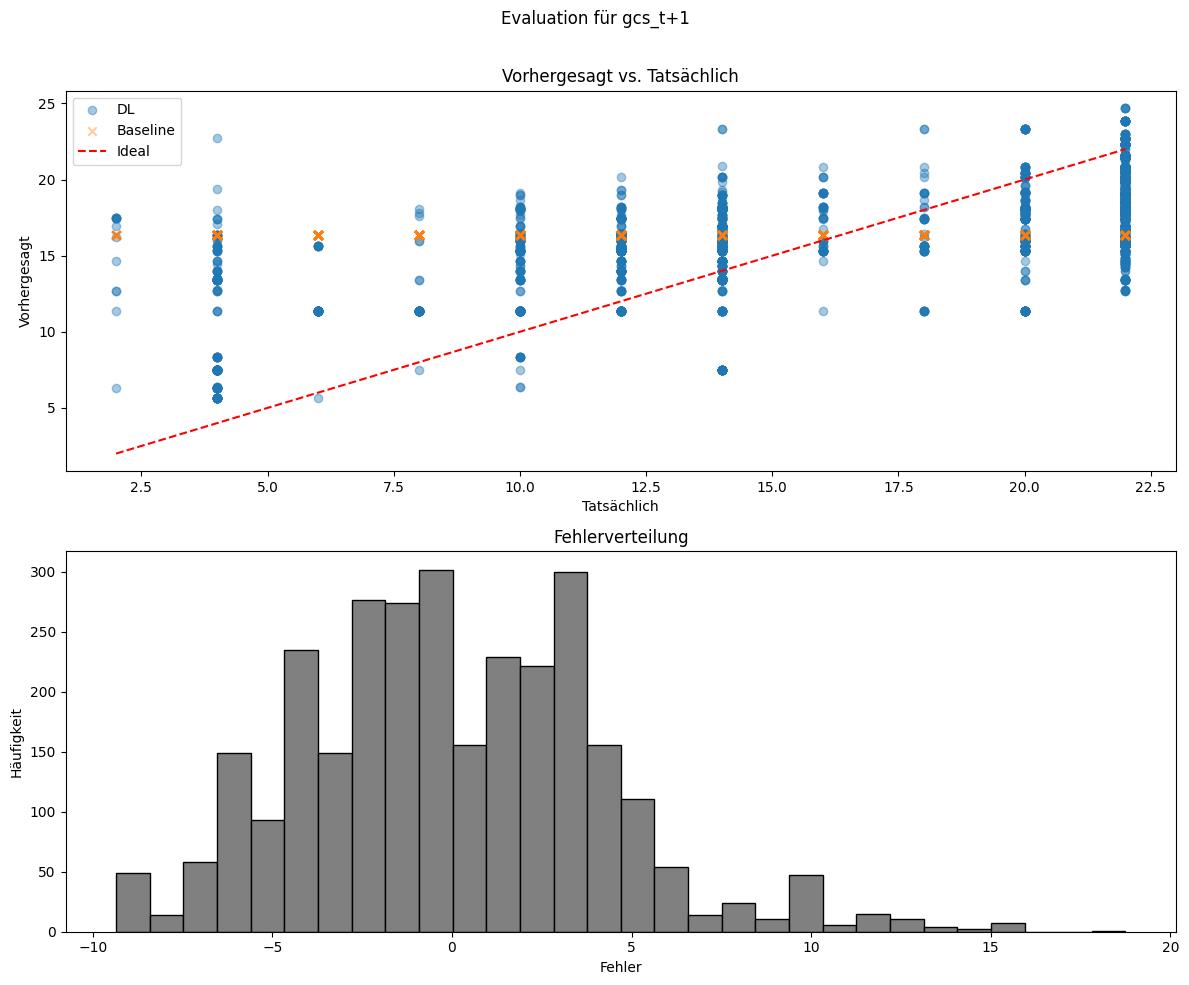

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 641us/step

Baseline (gcs_t+2) Metriken:
MAE:  5.10
MSE:  33.01
RMSE: 5.75
R²:   -0.00
MAPE: 51.10%

DL Modell (gcs_t+2) Metriken:
MAE:  3.31
MSE:  17.35
RMSE: 4.17
R²:   0.47
MAPE: 31.51%


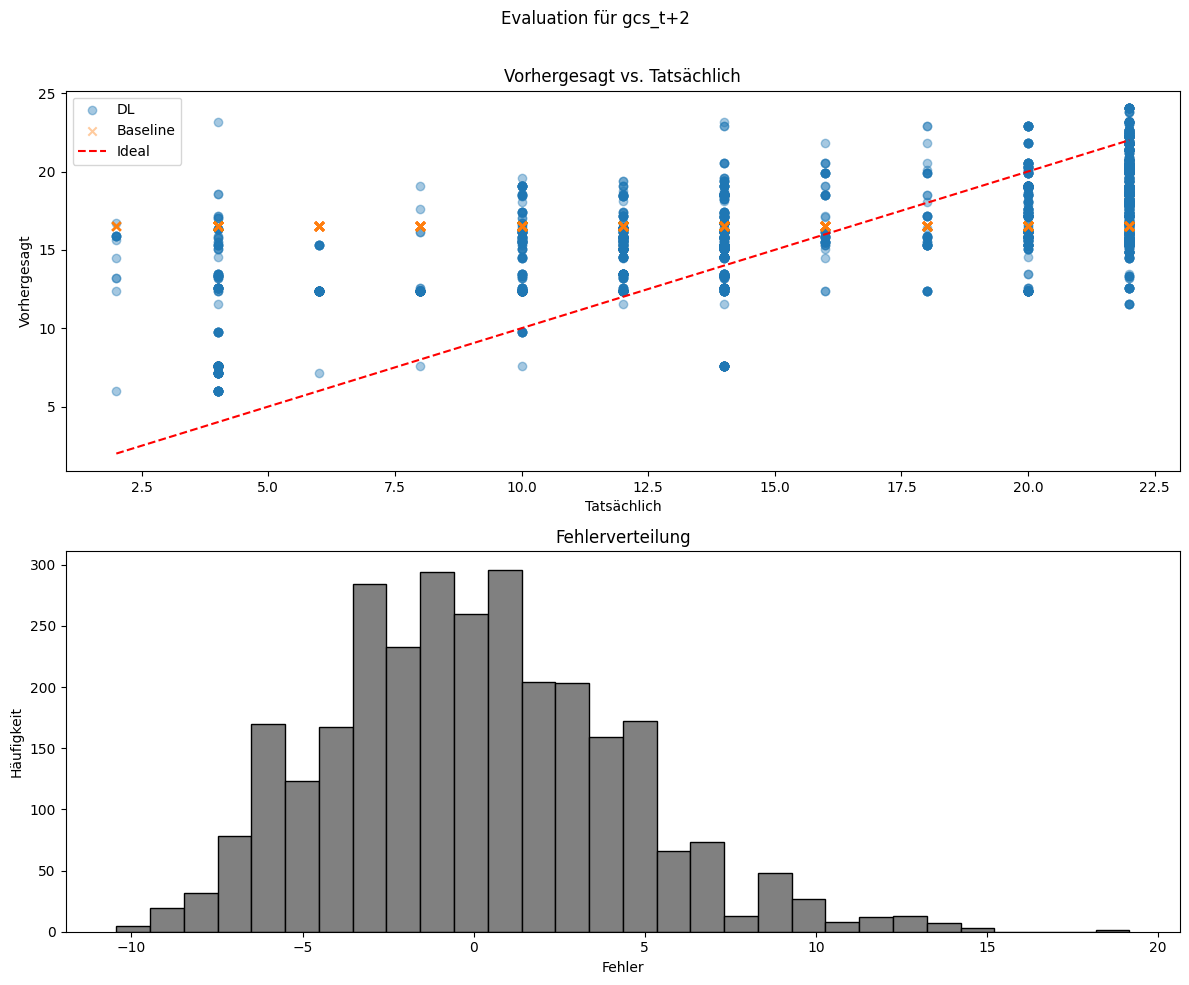

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 652us/step

Baseline (gcs_t+3) Metriken:
MAE:  5.09
MSE:  32.81
RMSE: 5.73
R²:   -0.00
MAPE: 50.75%

DL Modell (gcs_t+3) Metriken:
MAE:  3.33
MSE:  16.87
RMSE: 4.11
R²:   0.49
MAPE: 29.82%


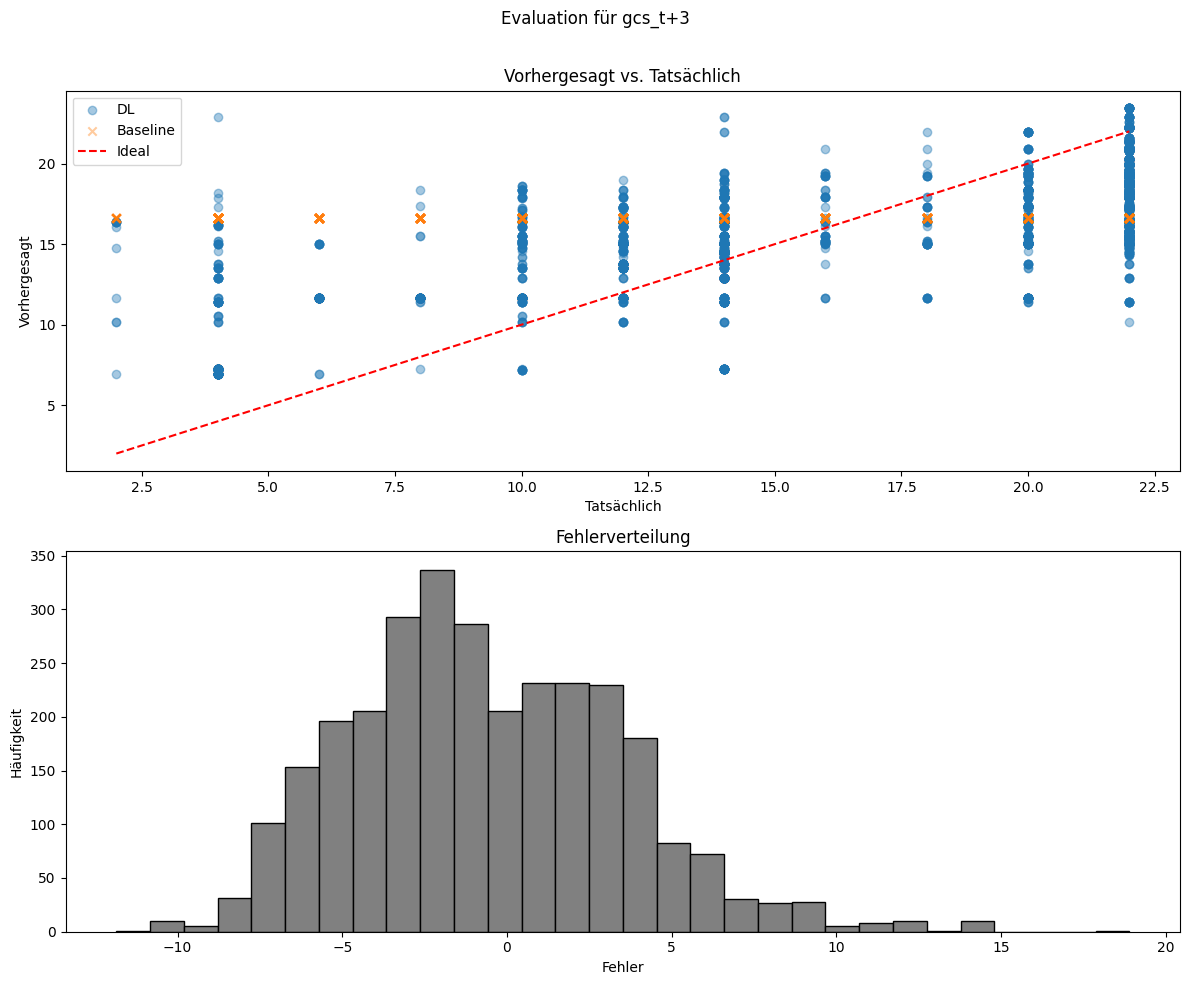

In [21]:
targets = {
    "gcs_t+1": (model_t1, baselin_t1),
    "gcs_t+2": (model_t2, baselin_t2),
    "gcs_t+3": (model_t3, baselin_t3),
}

for target, (model, baseline) in targets.items():
    y = df[target].values
    evaluate_and_plot(model, baseline, X_scaled, y, label=target)